# Vision Tracker Evaluation — RT-DETR + ByteTrack

Runs the RT-DETR model on all vision MOT sequences, compares predictions to GT, 
and reports standard MOT metrics.

**Model:** `solaqua_fish_improved_fix/rtdetr_fish_improved_f/weights/best.pt`   
**Class:** fish (class_id = 1)  
**Metric matching:** IoU ≥ 0.5

Run from `tracking/` directory.

In [1]:
print("Hello, World!")

Hello, World!


In [2]:
import sys
sys.path.insert(0, "..")  # make repo root importable

import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from tracking.utils.mot_metrics import (
    load_gt, run_inference, img_dir_for, frame_map,
    collect_images,
    compute_metrics, compute_hota, format_summary, build_summary_table,
    plot_metrics_bar, plot_error_breakdown,
    plot_track_comparison, plot_det_timeline, plot_id_switches,
)

plt.rcParams.update({"figure.dpi": 130, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})


/workspace/aquaculture-perception/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────────
REPO        = Path("..").resolve()
VISION_ROOT = REPO / "data-processing" / "vision" / "MOT"
MODEL_PATH  = REPO / "runs/detect/outputs/training/solaqua_fish_improved_fix/rtdetr_fish_improved_f/weights/best.pt"

# ── Sequence selection ─────────────────────────────────────────────────────────
# List specific sequence names to process, or leave empty to run all.
SELECTED_SEQUENCES = [
    "2024-08-20_14-31-29",
    # "2024-08-20_17-02-00",
    # "2024-08-20_17-14-36",
    # "2024-08-20_17-39-32",
    # "2024-08-20_17-55-40",
    
]

# ── Inference settings ─────────────────────────────────────────────────────────
CONF       = 0.25
IOU_NMS    = 0.45   # NMS threshold for detector
IOU_MATCH  = 0.5    # IoU threshold for GT<->pred matching
DEVICE     = "cuda:0"
FRAME_RATE = 30

# ── MOT output ────────────────────────────────────────────────────────────────
MOT_OUTPUT_DIR = Path("outputs/inference_annotation_MOT11")
MOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

all_seqs = sorted([p.name for p in VISION_ROOT.iterdir() if p.is_dir()])
SEQUENCES = [s for s in all_seqs if s in SELECTED_SEQUENCES] if SELECTED_SEQUENCES else all_seqs

print(f"Model   : {MODEL_PATH}")
print(f"Device  : {DEVICE}")
print(f"Sequences ({len(SEQUENCES)}):")
for s in SEQUENCES:
    print(f"  {s}")


Model   : /workspace/aquaculture-perception/runs/detect/outputs/training/solaqua_fish_improved_fix/rtdetr_fish_improved_f/weights/best.pt
Device  : cuda:0
Sequences (1):
  2024-08-20_14-31-29


## 1  Run inference on selected sequences
Edit `SELECTED_SEQUENCES` in the cell above to choose which sequences to process.  
Results are cached in memory and saved as MOT .txt files under `outputs/inference_annotation_MOT11/`.  
Re-run this cell to refresh.

In [4]:
gt_dfs   = {}   # {seq_name: gt DataFrame (fish only)}
pred_dfs = {}   # {seq_name: pred DataFrame (fish only)}
total_frames = {}

for seq in SEQUENCES:
    seq_path = VISION_ROOT / seq
    idir     = img_dir_for(seq_path, "vision")

    # Ground truth — fish only (class_id = 1)
    gt = load_gt(seq_path / "gt" / "gt.txt", idir, class_id=1)

    # Inference
    pred = run_inference(MODEL_PATH, idir,
                         conf=CONF, iou=IOU_NMS,
                         device=DEVICE, frame_rate=FRAME_RATE,
                         desc=seq)
    pred_fish = pred[pred["class_id"] == 1].copy()

    gt_dfs[seq]   = gt
    pred_dfs[seq] = pred_fish
    total_frames[seq] = len(list(idir.glob("*.jpg")))

    # ── Write MOT .txt (same format as tracking-inference_improved_MOT11.py) ──
    mot_lines = [
        f"{int(row.frame_id)},{int(row.track_id)},"
        f"{row.x:.2f},{row.y:.2f},{row.w:.2f},{row.h:.2f},"
        f"1,{int(row.class_id)},1.000000"
        for row in pred_fish.sort_values(["frame_id", "track_id"]).itertuples()
    ]
    mot_path = MOT_OUTPUT_DIR / f"INFERENCE_MOT11_{seq}.txt"
    mot_path.write_text("\n".join(mot_lines), encoding="utf-8")

    print(f"{seq}: GT={len(gt)} annots, Pred={len(pred_fish)} annots  "
          f"-> {mot_path.name}")


2024-08-20_14-31-29: 100%|██████████| 1500/1500 [01:26<00:00, 17.34it/s]

2024-08-20_14-31-29: GT=4967 annots, Pred=4549 annots  -> INFERENCE_MOT11_2024-08-20_14-31-29.txt


## 2  Compute metrics

In [5]:
accs    = {}
results = {}

for seq in SEQUENCES:
    acc, summary = compute_metrics(gt_dfs[seq], pred_dfs[seq], iou_threshold=IOU_MATCH)
    hota         = compute_hota(gt_dfs[seq], pred_dfs[seq])
    for k, v in hota.items():
        summary[k] = v

    accs[seq]    = acc
    results[seq] = summary
    print(f"{seq[-8:]}  "
          f"HOTA={hota['hota']*100:.1f}%  "
          f"MOTA={float(summary['mota'].iloc[0])*100:.1f}%  "
          f"IDF1={float(summary['idf1'].iloc[0])*100:.1f}%  "
          f"MOTP={float(summary['motp'].iloc[0])*100:.1f}%  "
          f"IDSW={int(summary['num_switches'].iloc[0])}")

print()
display(build_summary_table(results))

14-31-29  HOTA=81.2%  MOTA=89.1%  IDF1=87.9%  MOTP=6.7%  IDSW=22



,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,81.2%,77.3%,89.1%,89.1%,87.9%,6.7%,90.6%,98.9%,51,469,22,42,0,53


## 3  Metrics bar charts

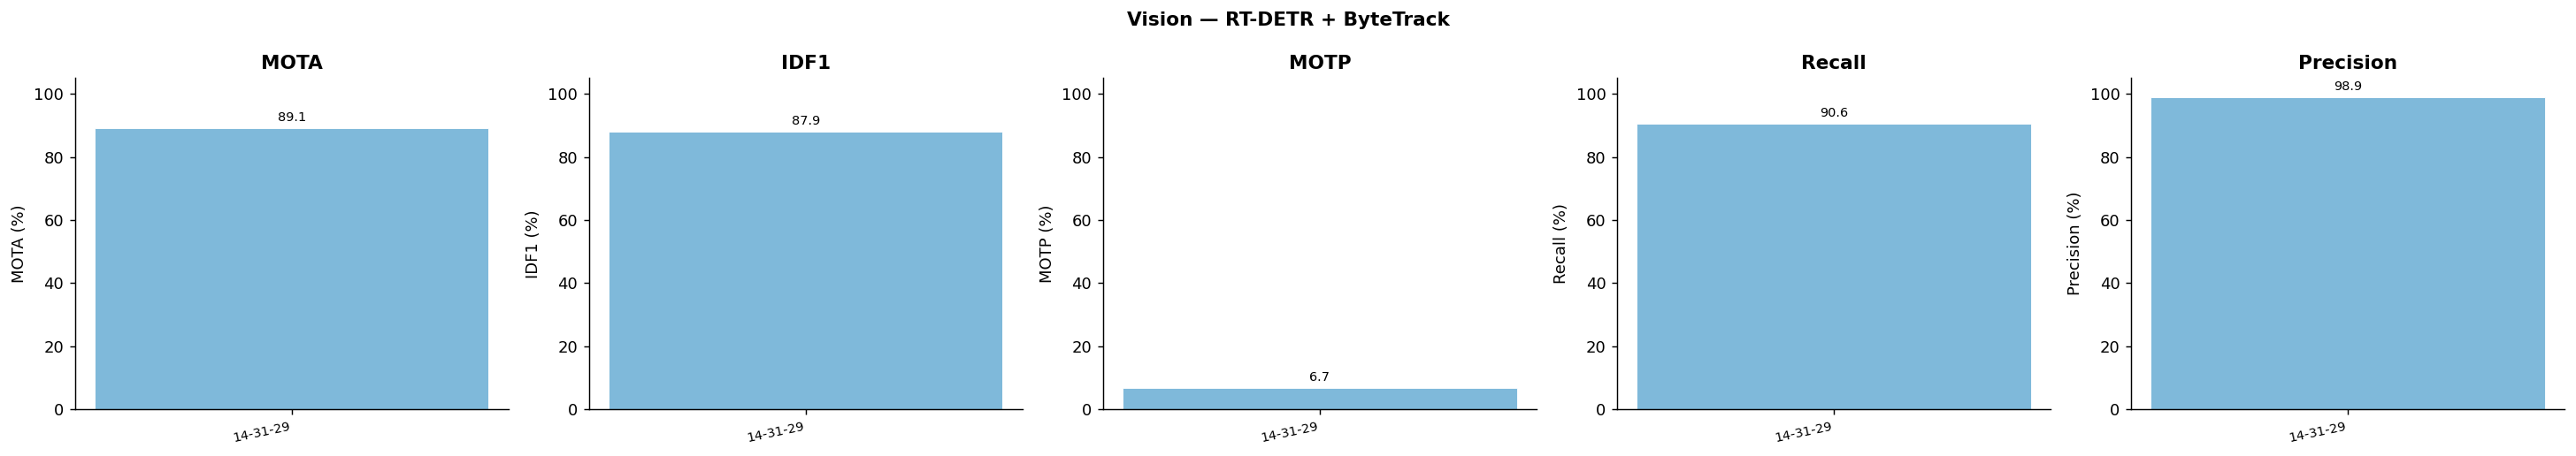

In [6]:
fig = plot_metrics_bar(results, metrics=("MOTA", "IDF1", "MOTP", "Recall", "Precision"),
                       title="Vision — RT-DETR + ByteTrack")
plt.savefig("outputs/vision_metrics_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## 4  Error breakdown — FP / FN / ID switches

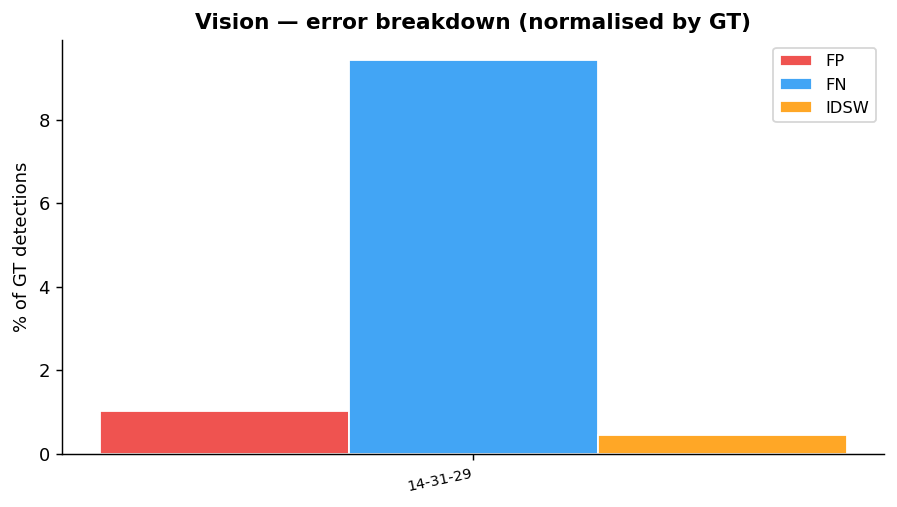

In [7]:
fig = plot_error_breakdown(results, title="Vision — error breakdown (normalised by GT)")
plt.savefig("outputs/vision_error_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

## 5  GT vs predicted track count

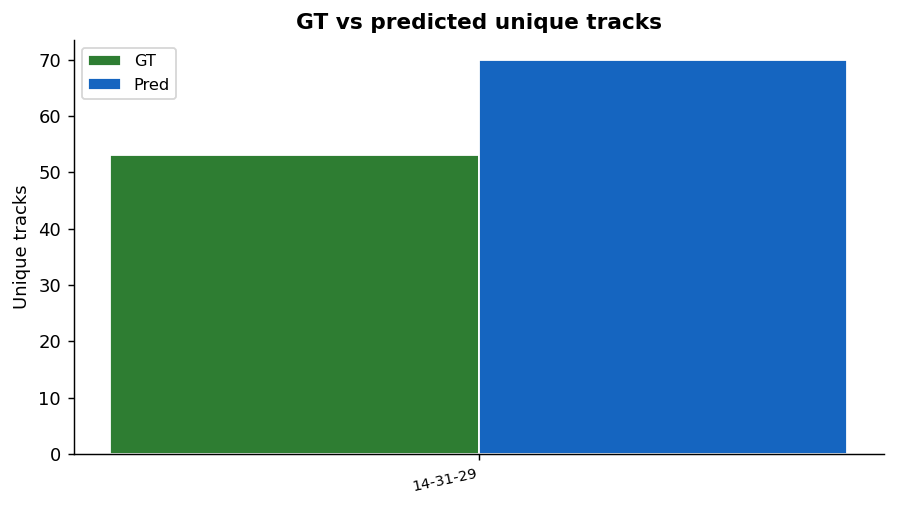

In [8]:
fig = plot_track_comparison(gt_dfs, pred_dfs)
plt.savefig("outputs/vision_track_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 6  Detection count per frame — GT vs predicted

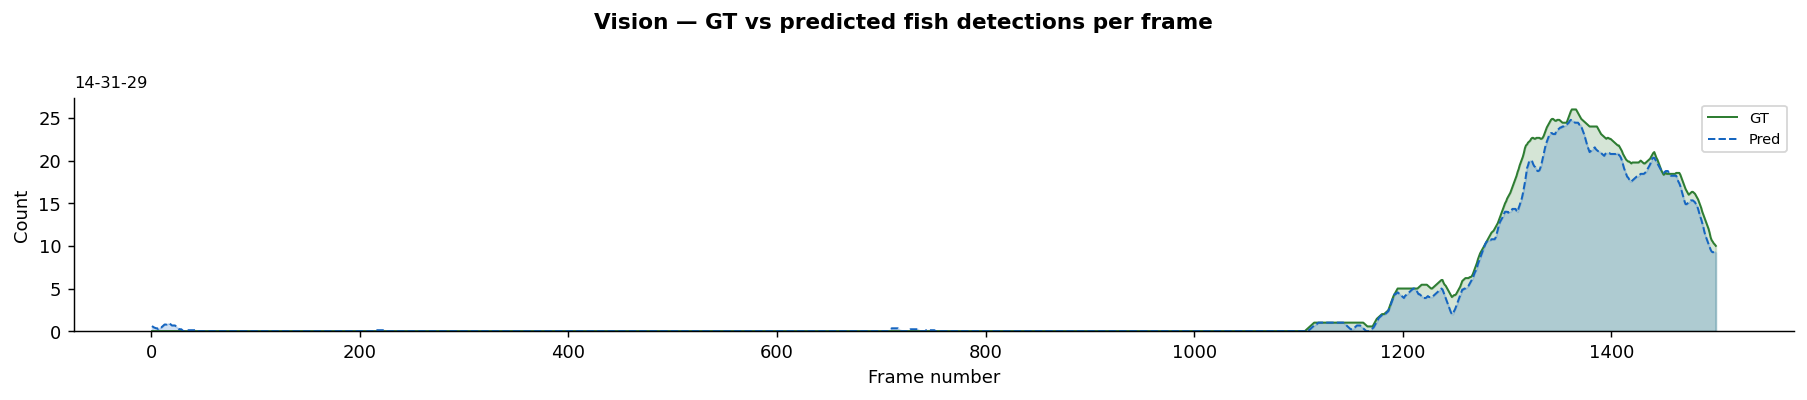

In [9]:
fig = plot_det_timeline(gt_dfs, pred_dfs, total_frames,
                        title="Vision — GT vs predicted fish detections per frame")
plt.savefig("outputs/vision_det_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

## 7  Cumulative ID switches over time

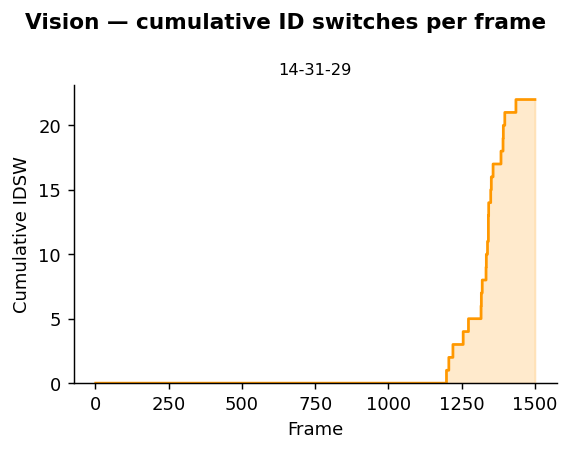

In [10]:
fig = plot_id_switches(accs, total_frames,
                       title="Vision — cumulative ID switches per frame")
plt.savefig("outputs/vision_id_switches.png", dpi=150, bbox_inches="tight")
plt.show()

## 8  MT / PT / ML breakdown
Mostly Tracked (>80% life covered), Partially Tracked, Mostly Lost (<20%).

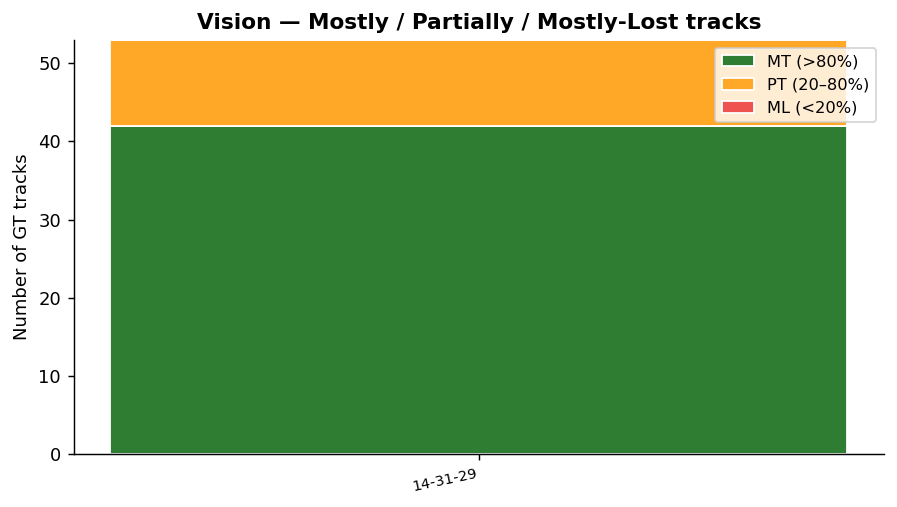

In [11]:
seq_names = list(results.keys())
mt_vals = [int(results[s]["mostly_tracked"].iloc[0])   for s in seq_names]
pt_vals = [int(results[s]["partially_tracked"].iloc[0]) for s in seq_names]
ml_vals = [int(results[s]["mostly_lost"].iloc[0])       for s in seq_names]

x = np.arange(len(seq_names))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x, mt_vals, label="MT (>80%)",  color="#2E7D32", edgecolor="white")
ax.bar(x, pt_vals, bottom=mt_vals, label="PT (20–80%)", color="#FFA726", edgecolor="white")
ax.bar(x, ml_vals, bottom=[m+p for m,p in zip(mt_vals,pt_vals)],
       label="ML (<20%)", color="#EF5350", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([s[-8:] for s in seq_names], rotation=12, ha="right", fontsize=8)
ax.set_ylabel("Number of GT tracks")
ax.set_title("Vision — Mostly / Partially / Mostly-Lost tracks", fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("outputs/vision_mt_pt_ml.png", dpi=150, bbox_inches="tight")
plt.show()

## V1  Track + trail visualization
Shows bounding boxes and track IDs for one frame, plus the trajectory
of each track as a line over the last `TRAIL_FRAMES` frames.
Edit `VIZ_SEQ`, `VIZ_FRAME_NORM`, and `TRAIL_FRAMES` to configure.

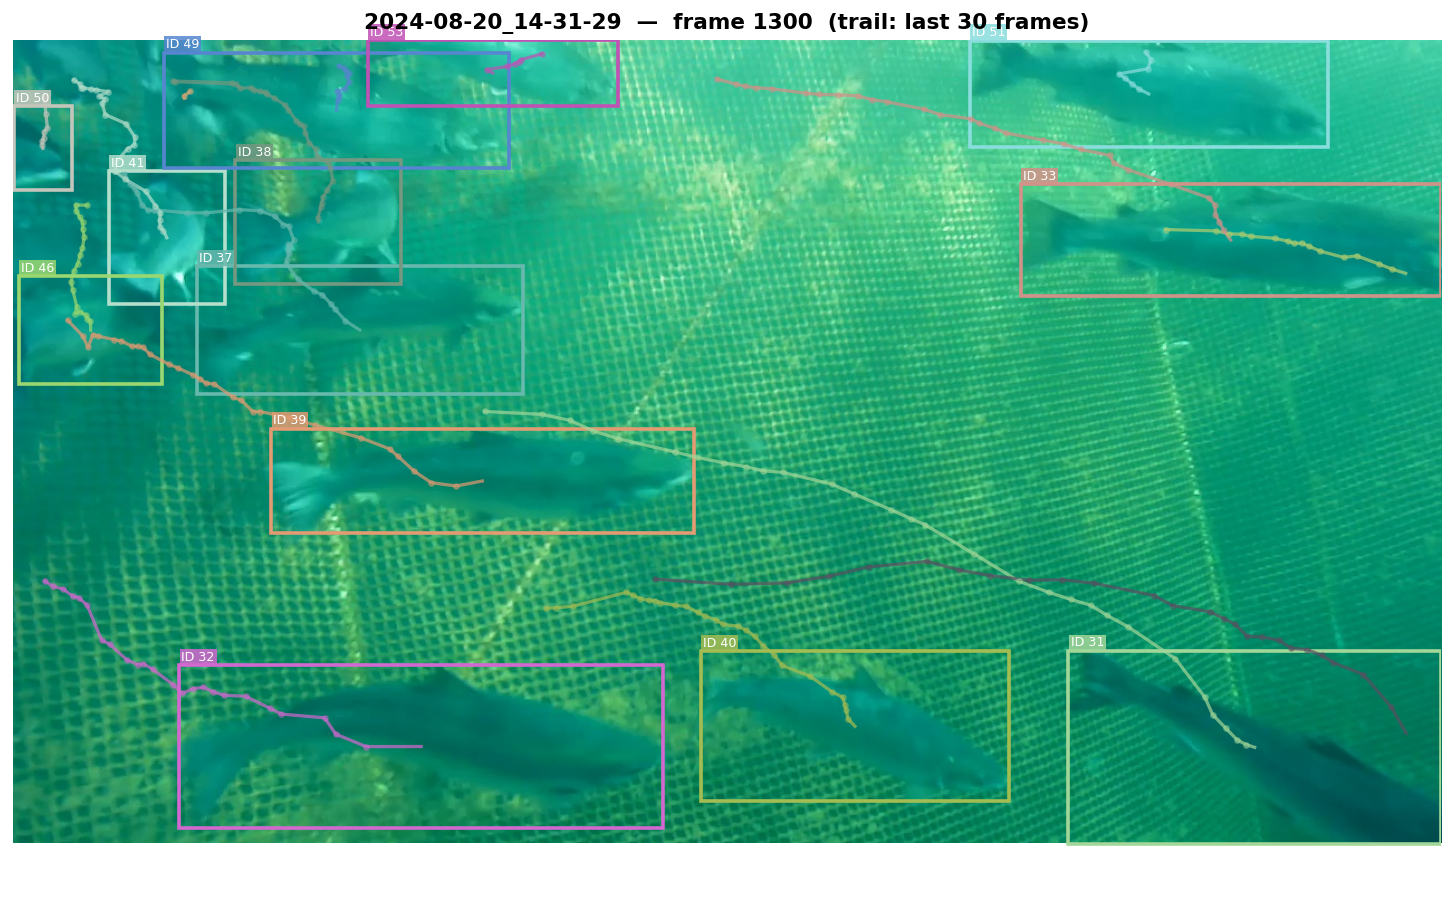

In [12]:
# ── Config ────────────────────────────────────────────────────────────────────
VIZ_SEQ        = SEQUENCES[0]   # sequence name
VIZ_FRAME_NORM = 1300             # frame to highlight (1-indexed sequential)
TRAIL_FRAMES   = 30             # how many past frames to draw as trail

# ── Load image ────────────────────────────────────────────────────────────────
idir      = img_dir_for(VISION_ROOT / VIZ_SEQ, "vision")
fn_to_img = {i + 1: p for i, p in enumerate(collect_images(idir))}

assert VIZ_FRAME_NORM in fn_to_img, f"Frame {VIZ_FRAME_NORM} not found in sequence"
img_rgb = cv2.cvtColor(cv2.imread(str(fn_to_img[VIZ_FRAME_NORM])), cv2.COLOR_BGR2RGB)

pred = pred_dfs[VIZ_SEQ]

# ── Per-track color (seeded by track id) ──────────────────────────────────────
def track_color(tid):
    rng = np.random.default_rng(seed=int(tid))
    return tuple(rng.integers(80, 230, size=3) / 255)

# ── Collect trails ────────────────────────────────────────────────────────────
trail_start = max(1, VIZ_FRAME_NORM - TRAIL_FRAMES + 1)
trail_df    = pred[(pred["frame_norm"] >= trail_start) &
                   (pred["frame_norm"] <= VIZ_FRAME_NORM)].copy()
trail_df["cx"] = trail_df["x"] + trail_df["w"] / 2
trail_df["cy"] = trail_df["y"] + trail_df["h"] / 2

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
ax.imshow(img_rgb)

# Draw trail lines
for tid, grp in trail_df.groupby("track_id"):
    grp = grp.sort_values("frame_norm")
    if len(grp) < 2:
        continue
    # Fade: older points more transparent
    c = track_color(tid)
    ax.plot(grp["cx"], grp["cy"], "-", color=c, lw=1.8, alpha=0.7)
    ax.scatter(grp["cx"].iloc[:-1], grp["cy"].iloc[:-1],
               s=8, color=c, alpha=0.4, zorder=3)

# Draw BBs + ID labels for the target frame
for _, row in pred[pred["frame_norm"] == VIZ_FRAME_NORM].iterrows():
    tid = int(row.track_id)
    c   = track_color(tid)
    ax.add_patch(plt.Rectangle((row.x, row.y), row.w, row.h,
                               linewidth=2, edgecolor=c, facecolor="none"))
    ax.text(row.x + 2, row.y - 4, f"ID {tid}", fontsize=7, color="white",
            bbox=dict(facecolor=c, alpha=0.85, pad=1, edgecolor="none"))

ax.set_title(f"{VIZ_SEQ}  —  frame {VIZ_FRAME_NORM}  "
             f"(trail: last {TRAIL_FRAMES} frames)", fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig("outputs/vision_trail_viz.png", dpi=150, bbox_inches="tight")
plt.show()


## V2  GT vs inference frame comparison
Green = ground truth boxes, red = predicted boxes.

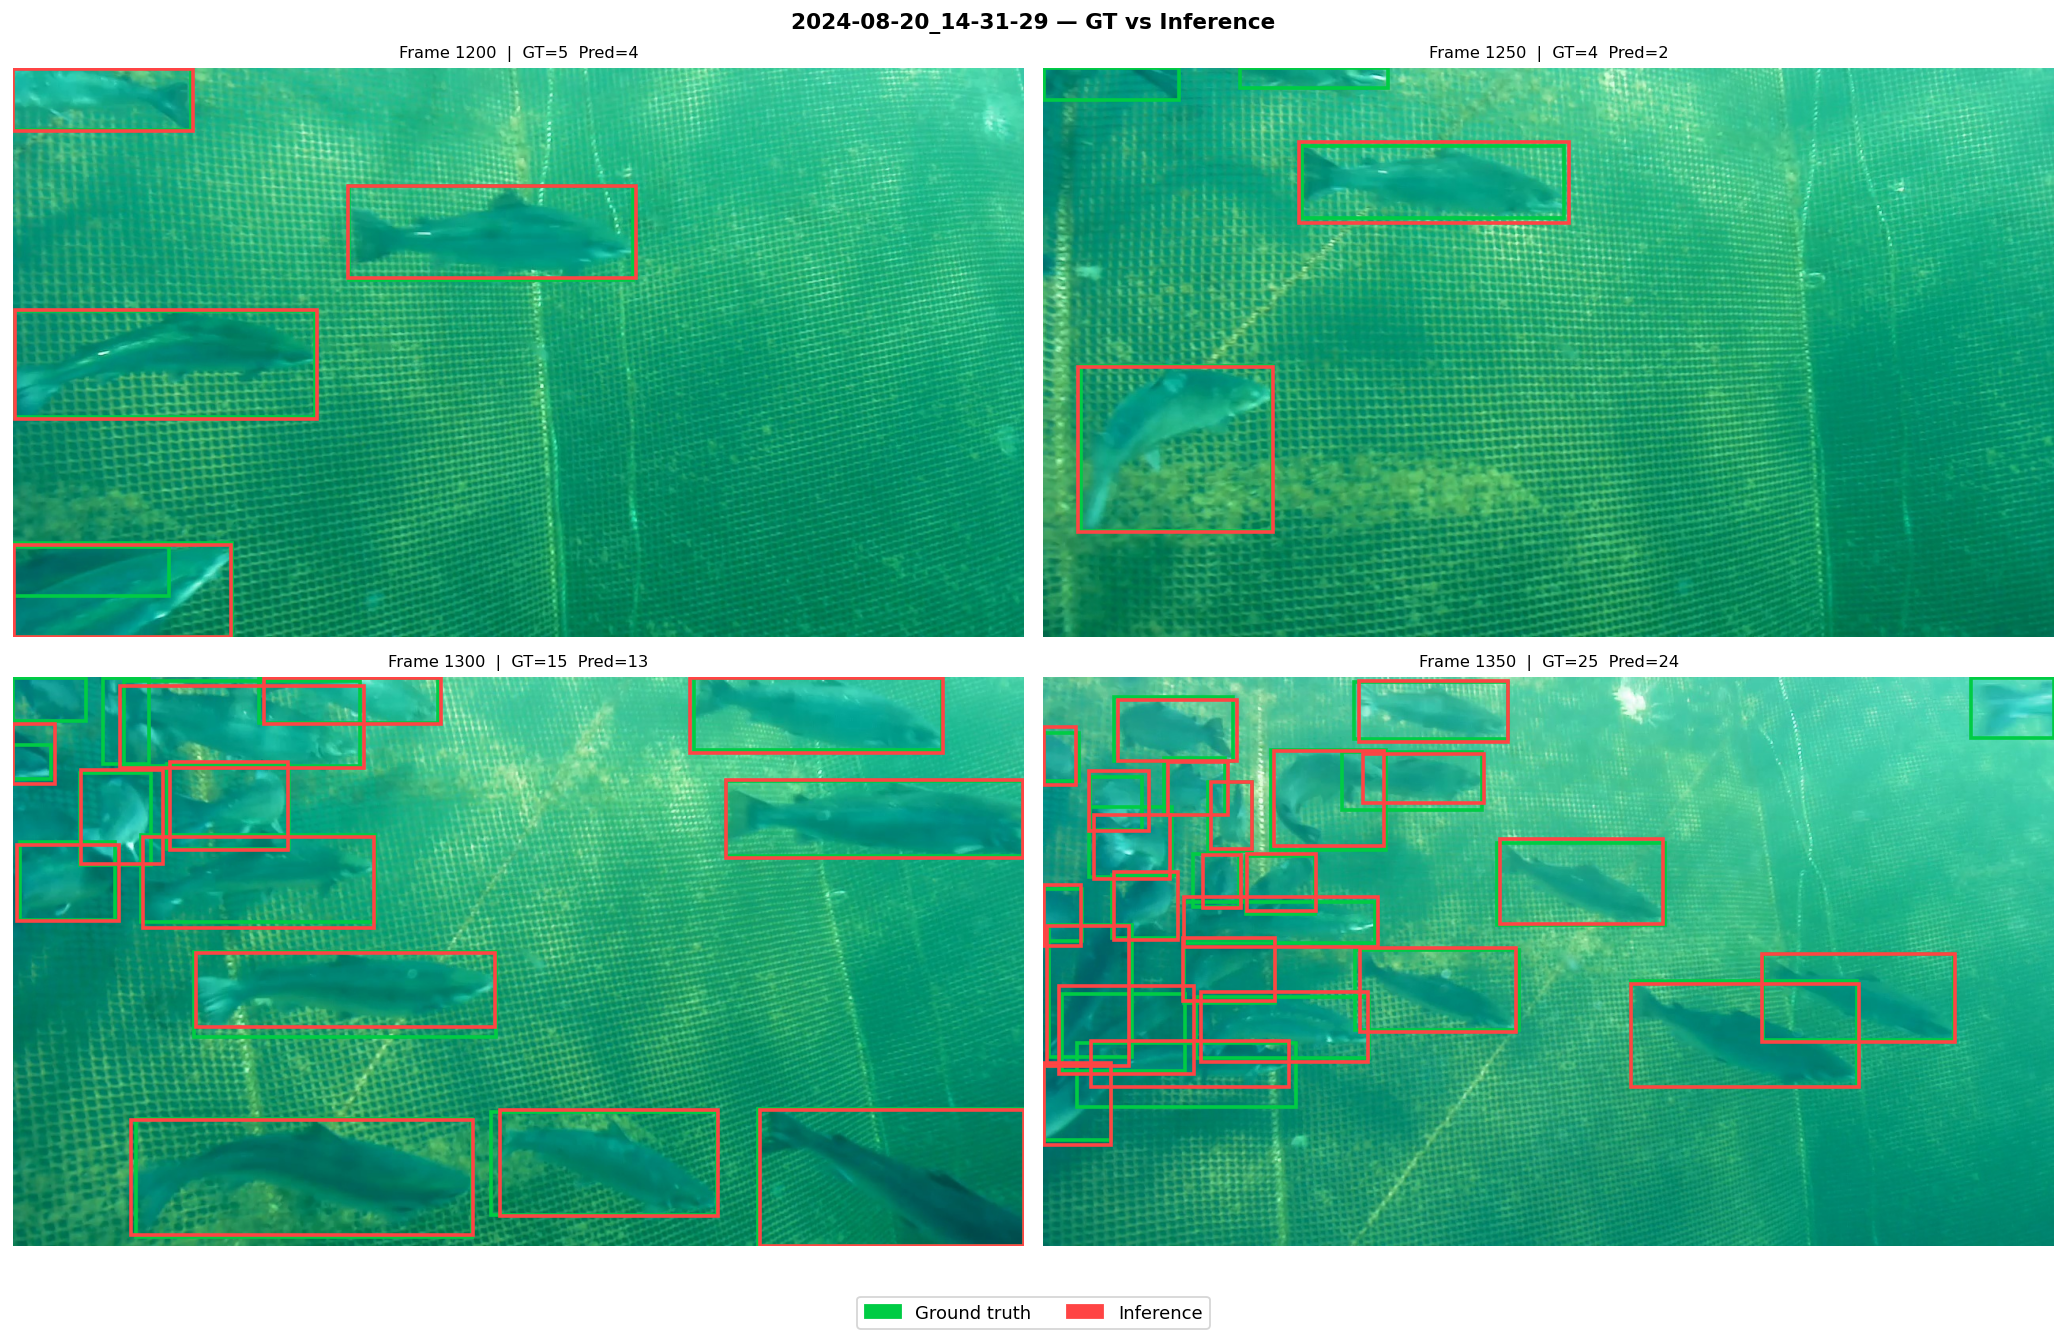

In [ ]:
# ── Config ────────────────────────────────────────────────────────────────────
COMPARE_SEQ    = SEQUENCES[0]
COMPARE_FRAMES = [1200, 1250, 1300, 1350]   # frame_norm indices (1-indexed sequential)
NCOLS          = 2

GT_COLOR   = "#00CC44"   # green
PRED_COLOR = "#FF4444"   # red

# ── Plot ──────────────────────────────────────────────────────────────────────
idir_c      = img_dir_for(VISION_ROOT / COMPARE_SEQ, "vision")
fn_to_img_c = {i + 1: p for i, p in enumerate(collect_images(idir_c))}
gt_c        = gt_dfs[COMPARE_SEQ]
pred_c      = pred_dfs[COMPARE_SEQ]

valid_frames = [fn for fn in COMPARE_FRAMES if fn in fn_to_img_c]
nrows = (len(valid_frames) + NCOLS - 1) // NCOLS
fig, axes = plt.subplots(nrows, NCOLS, figsize=(NCOLS * 8, nrows * 5))
axes = np.array(axes).flatten()

for i, fn in enumerate(valid_frames):
    ax = axes[i]
    img_rgb = cv2.cvtColor(cv2.imread(str(fn_to_img_c[fn])), cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)

    for _, row in gt_c[gt_c["frame_norm"] == fn].iterrows():
        ax.add_patch(plt.Rectangle((row.x, row.y), row.w, row.h,
                                   linewidth=2, edgecolor=GT_COLOR, facecolor="none"))

    for _, row in pred_c[pred_c["frame_norm"] == fn].iterrows():
        ax.add_patch(plt.Rectangle((row.x, row.y), row.w, row.h,
                                   linewidth=2, edgecolor=PRED_COLOR, facecolor="none"))

    n_gt   = (gt_c["frame_norm"]   == fn).sum()
    n_pred = (pred_c["frame_norm"] == fn).sum()
    ax.set_title(f"Frame {fn}  |  GT={n_gt}  Pred={n_pred}", fontsize=9)
    ax.axis("off")

for j in range(len(valid_frames), len(axes)):
    axes[j].set_visible(False)

fig.legend(
    handles=[
        mpatches.Patch(color=GT_COLOR,   label="Ground truth"),
        mpatches.Patch(color=PRED_COLOR, label="Inference"),
    ],
    loc="lower center", ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.04),
)
fig.suptitle(f"{COMPARE_SEQ} — GT vs Inference", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/vision_gt_vs_pred.png", dpi=150, bbox_inches="tight")
plt.show()

